In [1]:
# pipenv install pandas plotly matplotlib pingouin nbformat ipykernel scikit-learn optuna ipywidgets gradio

# EDA
import pandas as pd
import pingouin as pg
import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Hyperparams otimization
import optuna

# Exploratory Data Aanalysis

## Data load

In [2]:
# Load the Dataset
df_segments = pd.read_csv('./datasets/clients_segments.csv')
df_segments.head(10)

,economic_activity,monthly_revenue,number_of_employees,location,age,innovation,customer_segment
0,Commerce,713109.95,12,Rio de Janeiro,6,1,Bronze
1,Commerce,790714.38,9,São Paulo,15,0,Bronze
2,Commerce,1197239.33,17,São Paulo,4,9,Silver
3,Industry,449185.78,15,São Paulo,6,0,Starter
4,Agribusiness,1006373.16,15,São Paulo,15,8,Silver
5,Services,1629562.41,16,Rio de Janeiro,11,4,Silver
6,Services,771179.95,13,Vitória,0,1,Starter
7,Services,707837.61,16,São Paulo,10,6,Silver
8,Commerce,888983.66,17,Belo Horizonte,10,1,Bronze
9,Industry,1098512.64,13,Rio de Janeiro,9,3,Bronze


In [3]:
df_segments.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   economic_activity    500 non-null    str    
 1   monthly_revenue      500 non-null    float64
 2   number_of_employees  500 non-null    int64  
 3   location             500 non-null    str    
 4   age                  500 non-null    int64  
 5   innovation           500 non-null    int64  
 6   customer_segment     500 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 27.5 KB


In [ ]:
# Possible values for the categorical columns
print(F"Economic Activity - {df_segments['economic_activity'].unique()} \n")

print(F"Location - {df_segments['location'].unique()}\n")

print(F"Customer segment - {df_segments['customer_segment'].unique()}")

Economic Activity - <StringArray>
['Commerce', 'Industry', 'Agribusiness', 'Services']
Length: 4, dtype: str 

Location - <StringArray>
['Rio de Janeiro', 'São Paulo', 'Vitória', 'Belo Horizonte']
Length: 4, dtype: str

Customer segment - <StringArray>
['Bronze', 'Silver', 'Starter', 'Gold']
Length: 4, dtype: str


## Categorical Variable analysis 

In [5]:
# Creating a sorted list of target
target_list = ['Starter', 'Bronze', 'Silver', 'Gold']

In [6]:
# Distribution on target variable (Customer segment)
target_count = df_segments.value_counts('customer_segment')
target_count

customer_segment
Silver     260
Bronze     202
Starter     22
Gold        16
Name: count, dtype: int64

In [7]:
px.bar(target_count, color=target_count.index, category_orders={'customer_segment': target_list})

In [8]:
# Percentual distribution on target variable
target_percentual = (target_count / len(df_segments)) * 100
px.bar(target_percentual, color=target_percentual.index, category_orders={'customer_segment': target_list})

In [9]:
location_percentual = (df_segments.value_counts('location') / len(df_segments)) * 100
px.bar(location_percentual, color=location_percentual.index)

In [10]:
economic_percentual = (df_segments.value_counts('economic_activity') / len(df_segments)) * 100
px.bar(economic_percentual, color=economic_percentual.index)

In [11]:
# Contingence Table between Location and Target
location_crosstab = pd.crosstab(df_segments['location'], df_segments['customer_segment'], margins=True)[target_list].reset_index()

location_table = ff.create_table(location_crosstab)

location_table.show()

In [12]:
# Contingence Table between Economic Activity and Target
economic_crosstab = pd.crosstab(df_segments['economic_activity'], df_segments['customer_segment'], margins=True)[target_list].reset_index()

economic_table = ff.create_table(economic_crosstab)

economic_table.show()

In [13]:
# Contingence Table between Innovation and Target
innovation_crosstab = pd.crosstab(df_segments['innovation'], df_segments['customer_segment'], margins=True)[target_list].reset_index()

innovation_table = ff.create_table(innovation_crosstab)

innovation_table.show()

### Location X Customer Segment

In [14]:
# Pearson's chi-squared test
# H0 - The variables are independent
# H1 - The variables aren't independent
# If pvalue > 0.05 accept H0

expected_value, observed_value, stats = pg.chi2_independence(df_segments, 'customer_segment', 'location')

e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


In [15]:
# Expected Value - Frequency expected if there is no relation between the variables, calculated on basis with the distribution used no the chi-squared test
expected_value

location,Belo Horizonte,Rio de Janeiro,São Paulo,Vitória
customer_segment,,,,
Bronze,44.844,52.924,48.884,55.348
Gold,3.552,4.192,3.872,4.384
Silver,57.720,68.120,62.920,71.240
Starter,4.884,5.764,5.324,6.028


In [16]:
# Observed_value - The real frequency on colected data
observed_value

location,Belo Horizonte,Rio de Janeiro,São Paulo,Vitória
customer_segment,,,,
Bronze,39,62,45,56
Gold,4,3,5,4
Silver,63,60,65,72
Starter,5,6,6,5


In [17]:
stats.round(5)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.00000,5.19335,9.0,0.81714,0.05884,0.11369
1,cressie-read,0.66667,5.19198,9.0,0.81726,0.05883,0.11367
2,log-likelihood,0.00000,5.19713,9.0,0.81680,0.05886,0.11374
3,freeman-tukey,-0.50000,5.20798,9.0,0.81581,0.05892,0.11390
4,mod-log-likelihood,-1.00000,5.22494,9.0,0.81428,0.05902,0.11414
5,neyman,-2.00000,5.27777,9.0,0.80945,0.05932,0.11490


The variables location and customer segment are independent. (P-value = 0.81714)

### Economic Activity X Customer Segment

In [18]:
# Pearson's chi-squared test
# H0 - The variables are independent
# H1 - The variables aren't independent
# If pvalue > 0.05 accept H0

expected_value, observed_value, stats = pg.chi2_independence(df_segments, 'customer_segment', 'economic_activity')

e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: invalid value encountered in multiply
  terms

In [19]:
# Expected Value - Frequency expected if there is no relation between the variables, calculated on basis with the distribution used no the chi-squared test
expected_value

economic_activity,Agribusiness,Commerce,Industry,Services
customer_segment,,,,
Bronze,47.672,56.156,49.288,48.884
Gold,3.776,4.448,3.904,3.872
Silver,61.360,72.280,63.440,62.920
Starter,5.192,6.116,5.368,5.324


In [20]:
# Observed_value - The real frequency on colected data
observed_value

economic_activity,Agribusiness,Commerce,Industry,Services
customer_segment,,,,
Bronze,47,56,50,49
Gold,7,5,4,0
Silver,57,75,63,65
Starter,7,3,5,7


In [21]:
stats.round(5)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.00000,9.96998,9.0,0.35292,0.08153,0.18948
1,cressie-read,0.66667,10.60995,9.0,0.30339,0.08410,0.20060
2,log-likelihood,0.00000,13.54637,9.0,0.13940,0.09503,0.25375
3,freeman-tukey,-0.50000,NaN,9.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.00000,inf,9.0,0.00000,inf,NaN
5,neyman,-2.00000,NaN,9.0,NaN,NaN,NaN


The variables economic activity and customer segment are independent. (P-value = 0.35292)

### Innovation X Customer Segment

In [22]:
# Pearson's chi-squared test
# H0 - The variables are independent
# H1 - The variables aren't independent
# If pvalue > 0.05 accept H0

expected_value, observed_value, stats = pg.chi2_independence(df_segments, 'customer_segment', 'innovation')

e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: invalid value encountered in multiply
  terms

In [23]:
# Expected Value - Frequency expected if there is no relation between the variables, calculated on basis with the distribution used no the chi-squared test
expected_value

innovation,0,1,2,3,4,5,6,7,8,9
customer_segment,,,,,,,,,,
Bronze,21.008,23.028,22.624,19.392,17.372,17.372,21.816,21.412,18.988,18.988
Gold,1.664,1.824,1.792,1.536,1.376,1.376,1.728,1.696,1.504,1.504
Silver,27.040,29.640,29.120,24.960,22.360,22.360,28.080,27.560,24.440,24.440
Starter,2.288,2.508,2.464,2.112,1.892,1.892,2.376,2.332,2.068,2.068


In [24]:
# Observed_value - The real frequency on colected data
observed_value

innovation,0,1,2,3,4,5,6,7,8,9
customer_segment,,,,,,,,,,
Bronze,36,44,32,22,12,14,15,12,9,6
Gold,0,0,0,0,0,3,0,5,4,4
Silver,10,5,20,25,30,25,38,36,34,37
Starter,6,8,4,1,1,1,1,0,0,0


In [25]:
stats.round(5)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.00000,164.29399,27.0,0.0,0.33095,0.99850
1,cressie-read,0.66667,165.49946,27.0,0.0,0.33216,0.99861
2,log-likelihood,0.00000,181.48878,27.0,0.0,0.34784,0.99951
3,freeman-tukey,-0.50000,NaN,27.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.00000,inf,27.0,0.0,inf,NaN
5,neyman,-2.00000,NaN,27.0,NaN,NaN,NaN


The variables innovation and customer segment aren't independent. (P-value = 0.0)

## Numeric Variable analysis

In [26]:
# Distribution company age
px.histogram(df_segments, x="age")

In [27]:
# Distribution monthly revenue
px.histogram(df_segments, x="monthly_revenue")

In [28]:
# Box plot between age and segment
px.box(df_segments, x='customer_segment', y='age', color='customer_segment', category_orders={'customer_segment': target_list})

In [29]:
# Box plot between monthly revenue and segment
px.box(df_segments, x='customer_segment', y='monthly_revenue', color='customer_segment', category_orders={'customer_segment': target_list})

# Model Training & Model Validation

## Train

In [32]:
# Splitting X e y
X = df_segments.drop(columns=['customer_segment'])
y = df_segments['customer_segment']

In [33]:
# Pipeline
# OneHotEncode on categorical features
# Model Training

# Categorical features
categorical_features = ['economic_activity', 'location']

# Create a Transformer of categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Pipeline with pre processor and decision tree model
dt_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier())
    ]
)

In [35]:
# Crossvalidation
# Train the model with Cross Validation using StratifiedKfold because the classes are unbalanced
cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
metrics_result = cross_validate(dt_model, X, y, cv=cv_folds, scoring=['accuracy'], return_estimator=True)

In [36]:
metrics_result

{'fit_time': array([0.00751591, 0.00600028, 0.00399899]),
 'score_time': array([0.00551057, 0.0032115 , 0.00250697]),
 'estimator': [Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('onehot',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['economic_activity',
                                                     'location'])])),
                  ('classifier', DecisionTreeClassifier())]),
  Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('imputer',
             

In [ ]:
# Average of accuracy, taking into account the three splits
metrics_result['test_accuracy'].mean()

np.float64(0.4800519443041627)

In [ ]:
# Accuracy
# Total number of correct predictions / total number of predictions

## Metrics

In [39]:
# Making the predictions with Cross Validation
y_pred = cross_val_predict(dt_model, X, y, cv=cv_folds)

In [40]:
classification_report_str = classification_report(y, y_pred)

print(f'classification Report\n{classification_report_str}')

classification Report
              precision    recall  f1-score   support

      Bronze       0.40      0.37      0.39       202
        Gold       0.00      0.00      0.00        16
      Silver       0.53      0.63      0.57       260
     Starter       0.00      0.00      0.00        22

    accuracy                           0.48       500
   macro avg       0.23      0.25      0.24       500
weighted avg       0.44      0.48      0.46       500



e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programação\Rocketseat\ml_models_practice\04. Decision Tree Classifier\Company Segment Classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedM

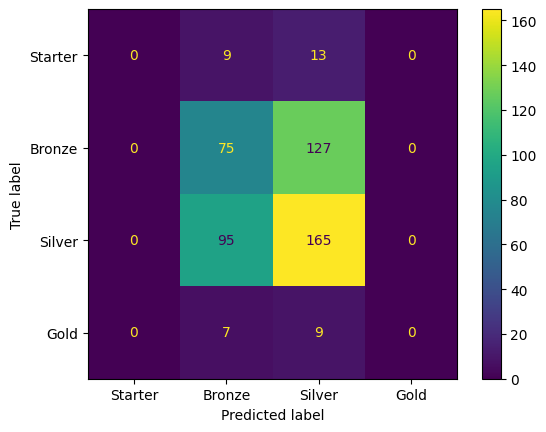

In [42]:
# Confusion matrix
model_confusion_matrix = confusion_matrix(y, y_pred, labels=target_list)
disp = ConfusionMatrixDisplay(model_confusion_matrix, display_labels=target_list)

disp.plot()

## Hyperparams tuning

In [46]:
# Tune hyperparameters using the library Optuna
# min_samples_leaf = Minimum number of instances required to form a leaf
# max_depth = Max depth of the tree

def decisiontree_optuna(trial):

    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_depth = trial.suggest_int('max_depth', 2, 8)

    dt_model.set_params(classifier__min_samples_leaf=min_samples_leaf)
    dt_model.set_params(classifier__max_depth=max_depth)

    scores = cross_val_score(dt_model, X, y, cv=cv_folds, scoring='accuracy')

    return scores.mean()

In [48]:
# Exec the experiment automation
decisiontree_study = optuna.create_study(direction='maximize')
decisiontree_study.optimize(decisiontree_optuna, n_trials=200)

[I 2026-06-01 17:41:46,750] A new study created in memory with name: no-name-f05be896-8cb5-4e2e-a286-6b7f945c53a0
[I 2026-06-01 17:41:46,786] Trial 0 finished with value: 0.4740278479186206 and parameters: {'min_samples_leaf': 16, 'max_depth': 8}. Best is trial 0 with value: 0.4740278479186206.
[I 2026-06-01 17:41:46,814] Trial 1 finished with value: 0.48600389582281217 and parameters: {'min_samples_leaf': 18, 'max_depth': 7}. Best is trial 1 with value: 0.48600389582281217.
[I 2026-06-01 17:41:46,843] Trial 2 finished with value: 0.4800519443041627 and parameters: {'min_samples_leaf': 1, 'max_depth': 8}. Best is trial 1 with value: 0.48600389582281217.
[I 2026-06-01 17:41:46,876] Trial 3 finished with value: 0.4779958155977202 and parameters: {'min_samples_leaf': 18, 'max_depth': 3}. Best is trial 1 with value: 0.48600389582281217.
[I 2026-06-01 17:41:46,905] Trial 4 finished with value: 0.48602794411177647 and parameters: {'min_samples_leaf': 20, 'max_depth': 4}. Best is trial 4 with

In [49]:
# Showing best score and set of hyperparams
print(F"Best accuracy: {decisiontree_study.best_value}")
print(F"Best params: {decisiontree_study.best_params}")

Best accuracy: 0.49997595171103576
Best params: {'min_samples_leaf': 20, 'max_depth': 2}


## Showing the Decision Tree

In [52]:
# Prepare the dataset for train and visualize the tree
X_train_tree = X.copy()
X_train_tree['location_label'] = X_train_tree.location.astype('category').cat.codes
X_train_tree['economic_activity_label'] = X_train_tree.economic_activity.astype('category').cat.codes

X_train_tree.drop(columns=['location', 'economic_activity'], inplace=True)
X_train_tree.rename(columns={'location_label': 'location', 'economic_activity_label': 'economic_activity'}, inplace=True)

X_train_tree.head(10)

,monthly_revenue,number_of_employees,age,innovation,location,economic_activity
0,713109.95,12,6,1,1,1
1,790714.38,9,15,0,2,1
2,1197239.33,17,4,9,2,1
3,449185.78,15,6,0,2,2
4,1006373.16,15,15,8,2,0
5,1629562.41,16,11,4,1,3
6,771179.95,13,0,1,3,3
7,707837.61,16,10,6,2,3
8,888983.66,17,10,1,0,1
9,1098512.64,13,9,3,1,2


In [ ]:
# Train the model with the ideal hyperparameters
clf_decisiontree = DecisionTreeClassifier(
    min_samples_leaf=decisiontree_study.best_params['min_samples_leaf'],
    max_depth=decisiontree_study.best_params['max_depth']
)

y_train_tree = y.copy()

clf_decisiontree.fit(X_train_tree, y_train_tree)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

[Text(0.5, 0.8333333333333334, 'innovation <= 2.5\ngini = 0.563\nsamples = 500\nvalue = [202, 16, 260, 22]\nclass = Silver'),
 Text(0.25, 0.5, 'monthly_revenue <= 517320.531\ngini = 0.482\nsamples = 165\nvalue = [112, 0, 35, 18]\nclass = Starter'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.455\nsamples = 20\nvalue = [7, 0, 0, 13]\nclass = Gold'),
 Text(0.375, 0.16666666666666666, 'gini = 0.416\nsamples = 145\nvalue = [105, 0, 35, 5]\nclass = Starter'),
 Text(0.75, 0.5, 'monthly_revenue <= 549601.438\ngini = 0.474\nsamples = 335\nvalue = [90.0, 16.0, 225.0, 4.0]\nclass = Silver'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.459\nsamples = 37\nvalue = [26, 0, 7, 4]\nclass = Starter'),
 Text(0.875, 0.16666666666666666, 'gini = 0.416\nsamples = 298\nvalue = [64.0, 16.0, 218.0, 0.0]\nclass = Silver')]

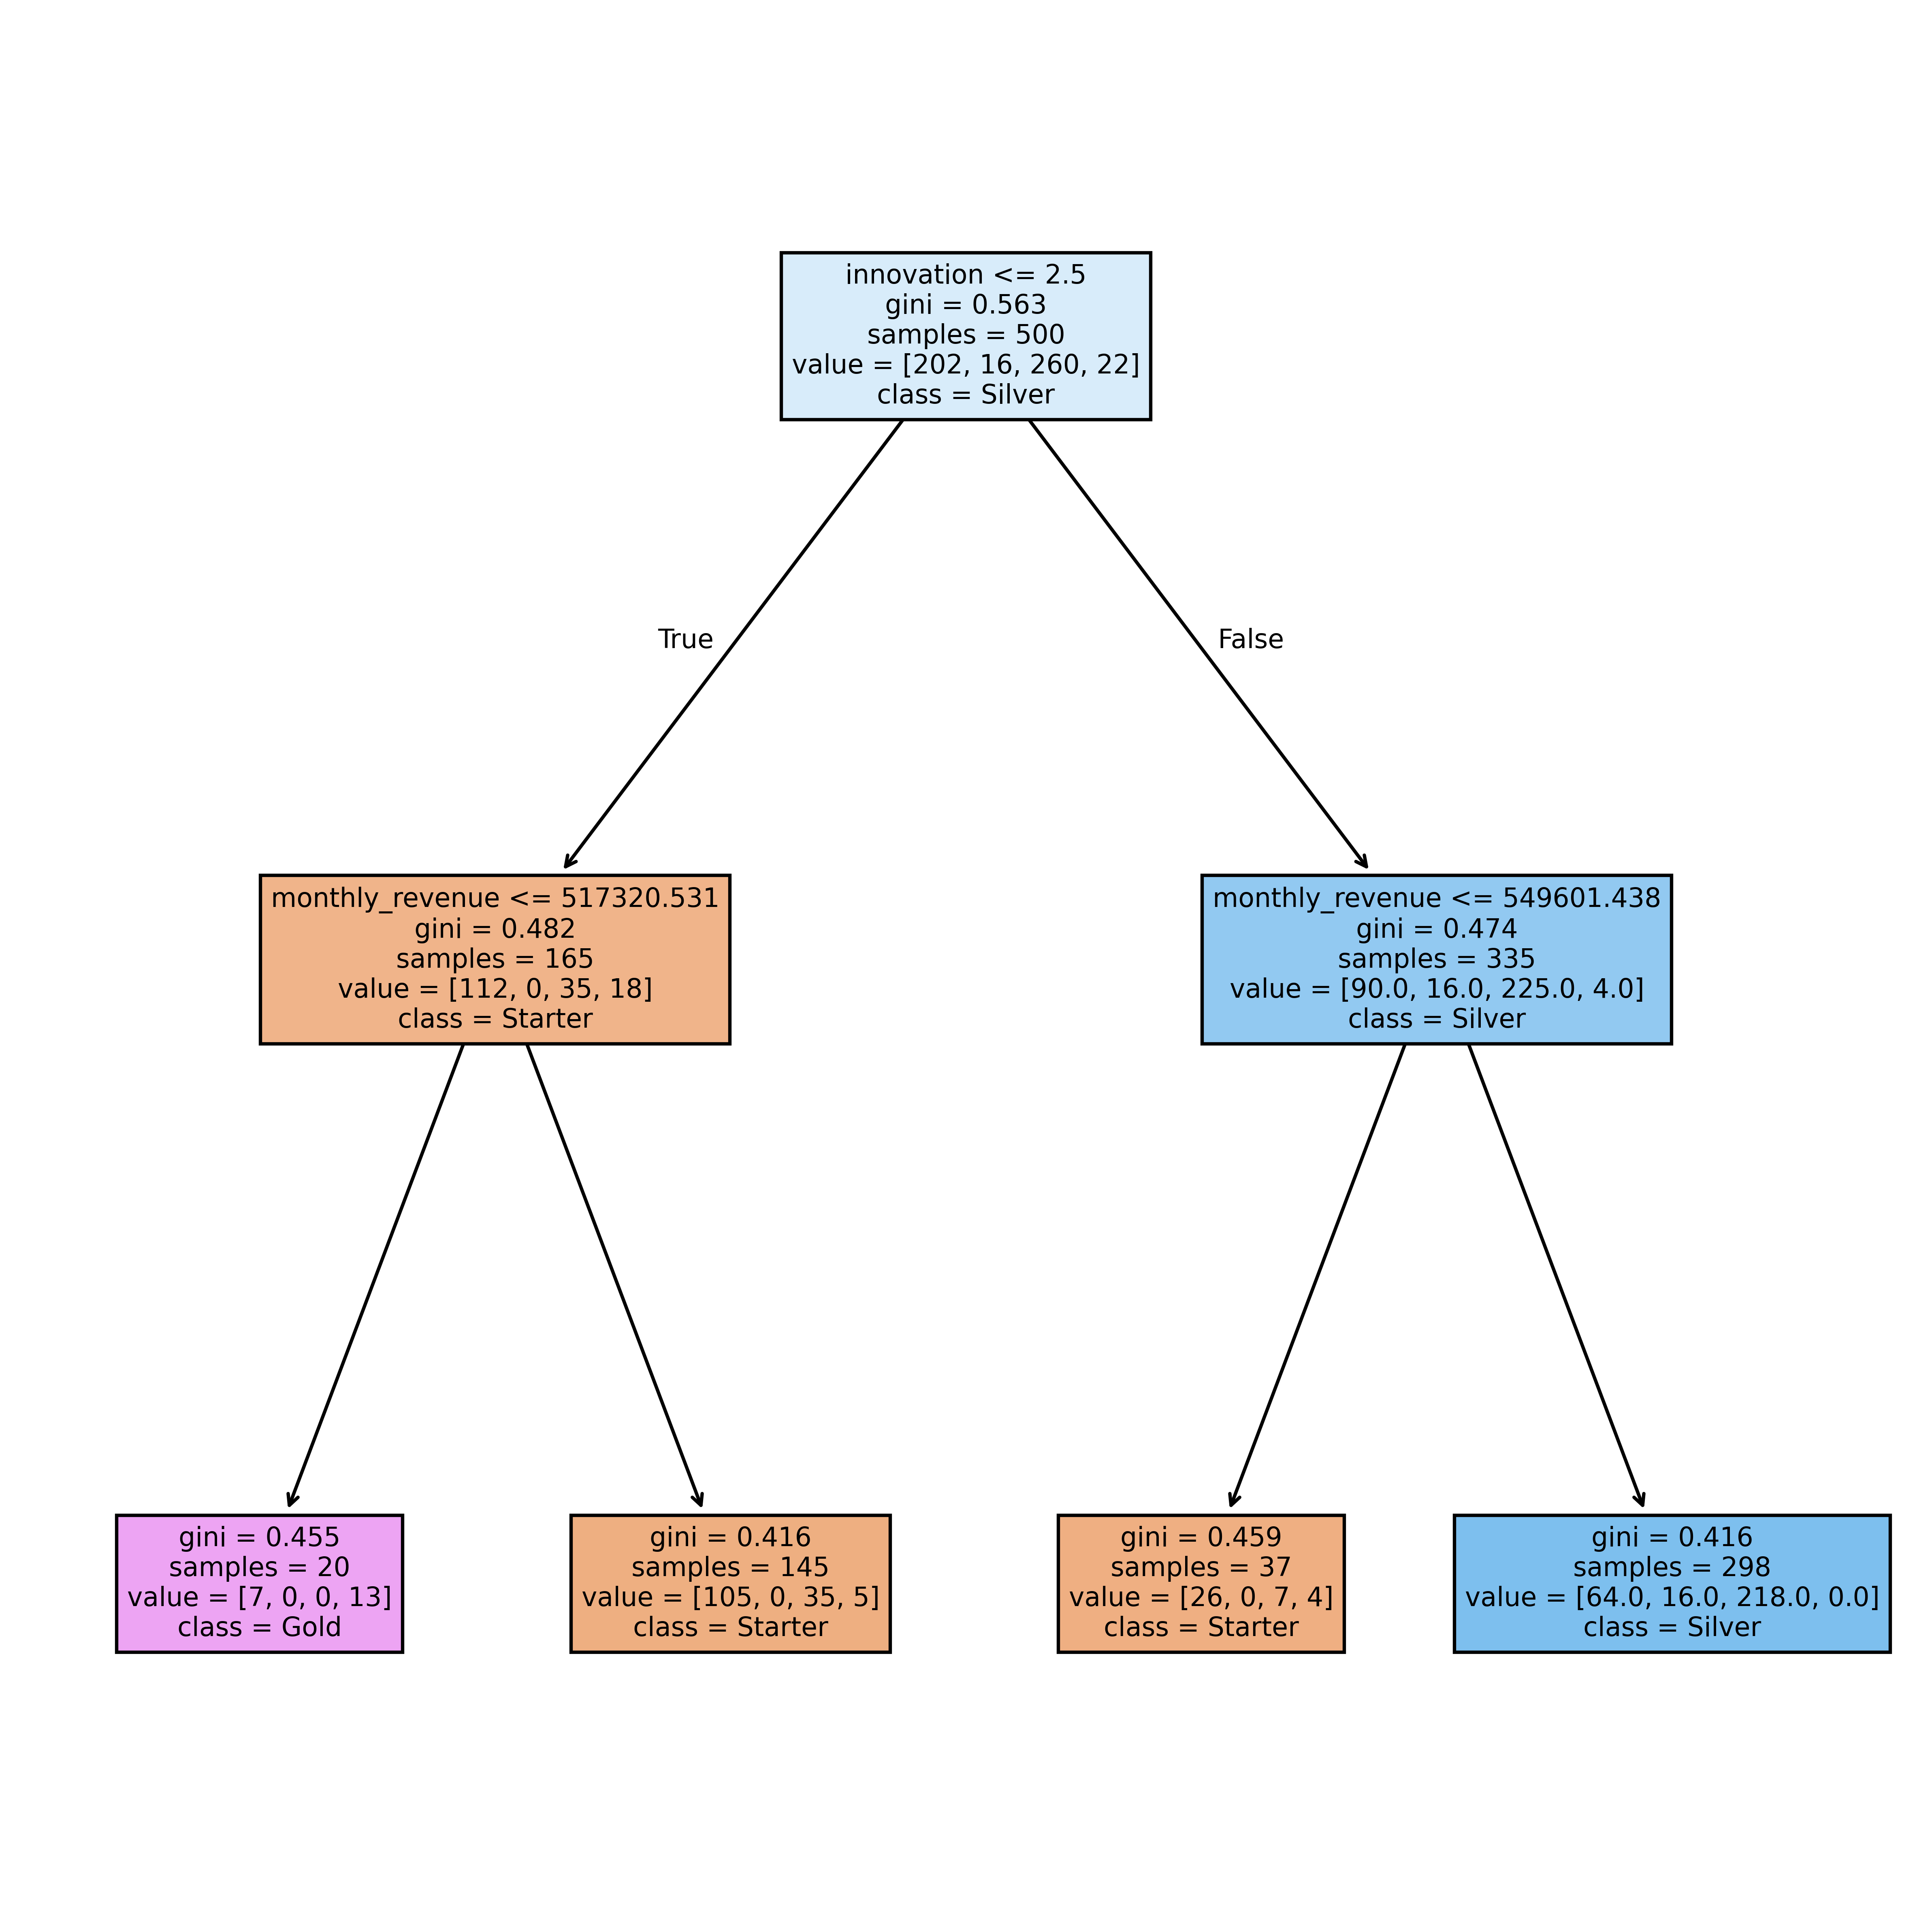

In [56]:
# Visualizing the decision tree
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,10), dpi=600)

plot_tree(clf_decisiontree, feature_names=X_train_tree.columns.to_numpy(), class_names=target_list ,filled=True)